In [1]:
import jax
from jax import config
from jax.nn import softplus
import jax.numpy as jnp
config.update("jax_enable_x64", True)
config.update("jax_platform_name", "cpu")
from utils.training_utils import K_func, ln_forward, current_map, make_rgc_forward_with_states 
from utils.utils import upsample_hold_edges
from utils.v_to_rate import voltage_batch_to_mu, make_edges
from utils.rgc import build_cell, simulate_one_trial, rgc_forward_sim
from utils.spk_detection import voltage_batch_to_spikes, idx_to_times

import matplotlib.pyplot as plt
import jaxley as jx
plt.rcParams["figure.dpi"] = 100
plt.rcParams['axes.labelsize'] = 18 

import seaborn as sns

In [2]:
from utils.stim_utils import generate_1_f_noise, plot_stim

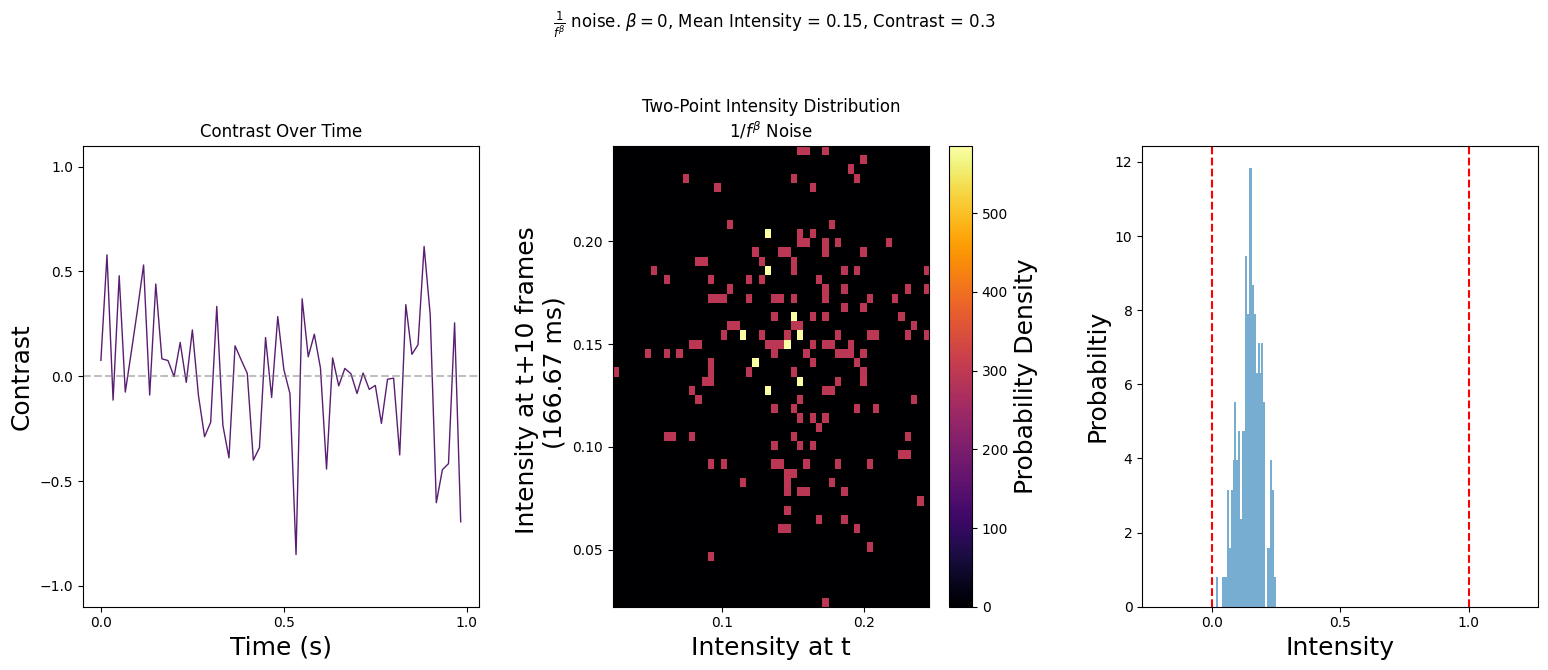

In [3]:
beta= 0
mean_intensity = 0.15
desired_contrast = 0.3
stim_duration = 1
trials = 3
frame_rate = 60
frame_dwell = 1
tau = 10

all_noise = []
all_contrast = []
for trial in range(trials):
    noise, contrast = generate_1_f_noise(
        beta, frame_rate * stim_duration, frame_rate,
        frame_dwell, mean_intensity, desired_contrast,
        noise_seed=trial)        
    all_noise.append(noise)
    all_contrast.append(contrast)

noise_t = jnp.concatenate(all_noise)
contrast_t = jnp.concatenate(all_contrast)
stim = jnp.array(all_contrast)

plot_stim(noise_t=noise_t, contrast_mat=stim, 
          beta=beta,
          mean_intensity=mean_intensity, 
          desired_contrast=desired_contrast, 
          tau=10, frame_rate=60, figsize=(16,7))

In [4]:
def softplus_inv(y, eps=1e-8):
    y = jnp.asarray(y, dtype=jnp.float32)
    return jnp.log(jnp.expm1(jnp.maximum(y, eps)))

def ln_params(key, 
              alpha_j0, 
              alpha_h0,
              logit_tau10, 
              logit_tau20,
              beta0, 
              shift0, 
              noise,
              DC, 
              scale, 
              beta_rate_raw,
              vth_rate):
    eps = noise * jax.random.normal(key, (6,), dtype=jnp.float32)
    return {
      "logit_tau1": jnp.array(logit_tau10, jnp.float32) + eps[0],
      "logit_tau2": jnp.array(logit_tau20, jnp.float32) + eps[1],
      "alpha_j":    jnp.array(alpha_j0,   jnp.float32)  * (1.0 + 0.1*eps[2]),
      "alpha_h":    jnp.array(alpha_h0,   jnp.float32)  * (1.0 + 0.1*eps[3]),
      "log_beta": softplus_inv(beta0) + eps[4],
      "shift":      jnp.array(shift0, jnp.float32) + 0.05*eps[5],
      "DC": jnp.array(DC, jnp.float32),
      "scale": jnp.array(scale, jnp.float32),
      "beta_rate_raw": jnp.array(beta_rate_raw, jnp.float32),
      "vth_rate": jnp.array(vth_rate, jnp.float32),
    }
    
    

In [5]:
import matplotlib.cm as cm
cmap = cm.viridis
frame_rate = 60
dt_stim = 1/frame_rate
dt_cell_s = 0.02e-3                  # seconds
dt_cell_ms = 0.02
key = jax.random.PRNGKey(0)
ground_params = ln_params(key, 
                        alpha_j0=0.16, 
                        alpha_h0=0.38,
                        logit_tau10=0.55, 
                        logit_tau20=-0.57,
                        beta0=2.3, 
                        shift0=0.304, 
                        noise=0.00,
                        DC=0.05, 
                        scale = 0.053, 
                        beta_rate_raw=0.0,
                        vth_rate=-0.0)


filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
drive, L, K_ground =  ln_forward(ground_params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)


In [14]:
max_tau

Array(0.19444445, dtype=float32)

In [6]:
I_frame = current_map(drive, ground_params)
T_f = I_frame.shape[-1]              # number of frames
T_cell = int(round(T_f * dt_stim / dt_cell_s))
I_syn = upsample_hold_edges(I_frame, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)

# Build cell
cell0 = build_cell()
cell0.delete_recordings()
cell0.record("v")
V_batch = rgc_forward_sim(I_syn, dt_cell_ms, cell0)  # dt_cell_ms should be in the same units integrate expects
print(V_batch.shape)

Added 1 recordings. See `.recordings` for details.
(3, 50000)


In [7]:
T_v = V_batch.shape[1]
edges_hat = make_edges(T_v, sr_v=1/dt_cell_s, fr=60.0)
rate_hat, mu_hat = voltage_batch_to_mu(V_batch, edges_hat, vth=-30, beta=0.5, r_max_hz=100, vcap=-20)

### Visualize V to rate diff transformation

In [ ]:

# fig, axes = plt.subplots(4,1, sharex=True, figsize=(7,7))
# t = jnp.arange(len(V_batch[1])) * dt_cell_s
# t_stim = jnp.arange(len(mu_hat[0]))/60
# axes[0].plot(t_stim, stim[0]) ; axes[0].plot(t_stim, stim[1])
# axes[1].plot(t, V_batch[0]); axes[1].plot(t, V_batch[1])
# axes[1].axhline(-45, ls="--", c='k')
# axes[1].set_ylim(-80, 0)
# axes[2].plot(t, rate_hat[0])

# axes[3].plot(t_stim, mu_hat[0]) ; axes[3].plot(t_stim, mu_hat[1])

# axes[0].set_ylabel("Contrast")
# axes[0].set_ylim(-1,1)
# axes[1].set_ylabel("Vm (mV)")
# axes[2].set_ylabel("Rate \n (Hz)")
# axes[3].set_ylabel("E[count]\n/frame")
# axes[3].set_xlabel("Time (s)")

# fig.tight_layout()

## Spike detection

In [8]:
T_v = V_batch.shape[1]
edges_hat = make_edges(T_v, sr_v=1/dt_cell_s, fr=60.0)


spk_bool, spk_idx_padded, n_spk, spk_train_60 = voltage_batch_to_spikes(
    V_batch,
    dt_v=dt_cell_s,
    edges=edges_hat,
    vth=0.0,        # try 0mV first; if too strict/lenient change to e.g. -10 or +10
    refrac_ms=2.0
)

spk_times_padded = idx_to_times(spk_idx_padded, dt_cell_s)

print("spk_bool:", spk_bool.shape)                 # (50, T_v)
print("spk_train_60:", spk_train_60.shape)         # (50, T_f)
print("n_spk (first 10):", n_spk[:10])


spk_bool: (3, 50000)
spk_train_60: (3, 60)
n_spk (first 10): [20 30 39]


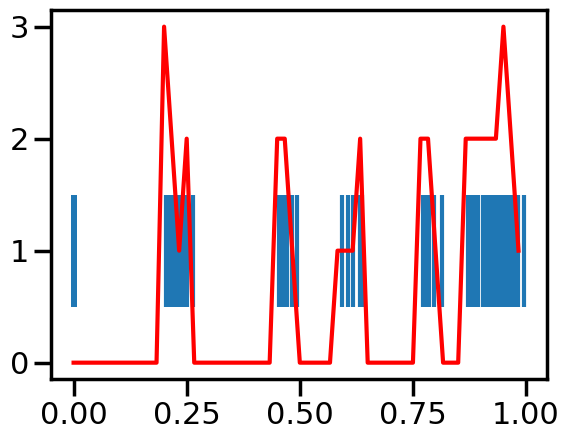

In [9]:
_ = jnp.arange(spk_train_60.shape[1]) / 60
plt.eventplot(spk_times_padded[2])
plt.plot(_, spk_train_60[2], c='red')

In [ ]:
# from jax.lax import stop_gradient
# import jax
# import jaxley as jx
# def choose_checkpoint_lengths(T, chunk=2048):
#     # ensures prod(checkpoint_lengths) >= T
#     # single-level is simplest
#     return [int(((T + chunk - 1) // chunk) * chunk)]

# def make_rgc_forward_with_states(cell, dt_cell, warmup_ms=200.0):
#     _, init_states = jx.integrate(cell, t_max=warmup_ms, delta_t=dt_cell, return_states=True)

#     def simulate_one(I_one):
#         data_stimuli = cell.data_stimulate(current=I_one, data_stimuli=None, verbose=False)
#         T = I_one.shape[0]
#         ckpt = choose_checkpoint_lengths(T, chunk=2048)

#         v = jx.integrate(
#             cell,
#             delta_t=dt_cell,
#             data_stimuli=data_stimuli,
#             all_states=stop_gradient(init_states),
#             checkpoint_lengths=ckpt,
#         )
#         return v[0, :-1]

#     def forward(I_syn):
#         if I_syn.ndim == 1:
#             I_syn_b = I_syn[None, :]
#         else:
#             I_syn_b = I_syn
#         return jax.vmap(simulate_one)(I_syn_b)

#     return forward



In [ ]:
# cell0 = build_cell()
# cell0.delete_recordings()
# cell0.record("v")

# rgc_forward = make_rgc_forward_with_states(cell0, dt_cell_ms)

# V0 = rgc_forward(I_syn[:2])
# print("non-jit:", V0.shape, V0.device)

# V1 = jax.jit(rgc_forward)(I_syn[:2])
# print("jit:", V1.shape, V1.device)

##Added 1 recordings. See `.recordings` for details.
## non-jit: (2, 100000) TFRT_CPU_0
## jit: (2, 100000) TFRT_CPU_0

## Recover LN params from sim data

In [ ]:
# def init_fit_params(key):
#     z = jax.random.normal(key, (6,), dtype=jnp.float32)

#     return {
#         "logit_tau1": jnp.array(0.55, jnp.float32) + 0.3*z[0],
#         "logit_tau2": jnp.array(-0.57, jnp.float32) + 0.3*z[1],
#         "alpha_j":    jnp.array(0.16, jnp.float32) * (1.0 + 0.3*z[2]),
#         "alpha_h":    jnp.array(0.38, jnp.float32) * (1.0 + 0.3*z[3]),
#         "log_beta":   jnp.log(jnp.array(2.3, jnp.float32)) + 0.3*z[4],
#         "shift":      jnp.array(0.30, jnp.float32) + 0.05*z[5],
#         "DC":         jnp.array(0.05, jnp.float32),
#         "scale":      jnp.array(0.053, jnp.float32),
#         "beta_rate_raw": jnp.array(0.0, jnp.float32),
#         "vth_rate":      jnp.array(-30.0, jnp.float32),
#     }


# def init_fit_params(key):
#     k1, k2 = jax.random.split(key, 2)

#     def n():
#         return jax.random.normal(k2, (), dtype=jnp.float32)

#     p = {
#         # --- LN kernel params (random init) ---
#         "logit_tau1": jnp.array(0.5, dtype=jnp.float32) + 0.5 * n(),
#         "logit_tau2": jnp.array(0.7, dtype=jnp.float32) + 0.5 * n(),
#         "alpha_j":    jnp.array(1.0, dtype=jnp.float32) * (1.0 + 0.3 * n()),
#         "alpha_h":    jnp.array(0.5, dtype=jnp.float32) * (1.0 + 0.3 * n()),
#         "log_beta":   jnp.array(-1.0, dtype=jnp.float32) + 0.5 * n(),
#         "shift":      jnp.array(0.1, dtype=jnp.float32) + 0.05 * n(),

#         # --- Current-map params (random or fixed; choose) ---
#         "DC":         jnp.array(0.05, dtype=jnp.float32),   # could also randomize
#         "scale":      jnp.array(0.05, dtype=jnp.float32),   # could also randomize

#         # --- Voltage -> rate head (2 params) ---
#         "beta_rate_raw": jnp.array(0.0, dtype=jnp.float32),     # softplus -> ~0.693
#         "vth_rate":      jnp.array(-30.0, dtype=jnp.float32),   # mV
#     }
#     return p


In [19]:
import matplotlib.cm as cm
cmap = cm.viridis
frame_rate = 60
dt_stim = 1/frame_rate
dt_cell_s = 0.02e-3                  # seconds
dt_cell_ms = 0.02
key2 = jax.random.PRNGKey(1)
# params_ln0 = init_fit_params(key2)
params_ln0 = ln_params(key2, alpha_j0=0.16, 
                        alpha_h0=0.38,
                        logit_tau10=0.01, 
                        logit_tau20=-0.01,
                        beta0=0.5, 
                        shift0=0.30, 
                        noise=0.5,
                        DC=0.05, 
                        scale = 0.053,
                        beta_rate_raw=0.0,
                        vth_rate=-30.0)

filt_dur = 0.6

K_T = int(round(filt_dur / float(dt_stim)))
max_tau = jnp.array(((K_T - 1) / 3.0) * float(dt_stim), dtype=jnp.float32)
drive, L, K0 =  ln_forward(params_ln0, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)

/tmp/ipykernel_8908/1407044337.py:31: UserWarning: The figure layout has changed to tight
  fig.tight_layout(w_pad=0.1)


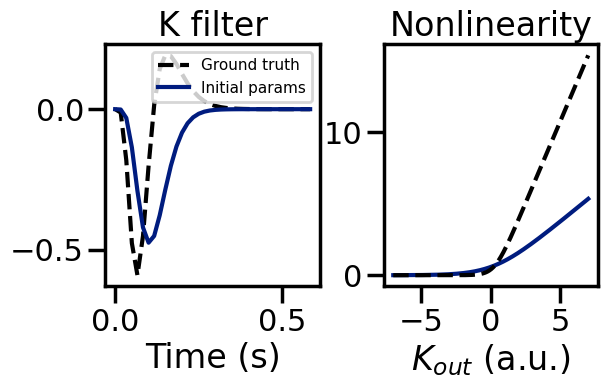

In [20]:
from jax.numpy.linalg import norm
t_k = jnp.arange(len(drive[0]))/frame_rate
# sns.set_palette("dark")
fig, axes = plt.subplots(1, 2, figsize=(6*1.1, 4*1.1),  layout="constrained")


axes[0].plot(jnp.arange(len(K_ground))*dt_stim, K_ground/norm(K_ground), c='k', ls="--", label='Ground truth',)

axes[0].plot(jnp.arange(len(K0))*dt_stim, K0/norm(K0), c=sns.color_palette("dark")[0], label='Initial params')

axes[0].set_xlabel("Time (s)")
axes[0].set_title("K filter")

axes[1].set_title("Nonlinearity")

x = jnp.linspace(-7, 7, 300)

beta0  = softplus(params_ln0["log_beta"]) + 1e-6
shift0 = params_ln0["shift"]
nl0 = softplus(beta0 * (x - shift0))

beta_ground  = softplus(ground_params["log_beta"]) + 1e-6
shift_ground = ground_params["shift"]
nl_ground = softplus(beta_ground * (x - shift_ground))


axes[1].plot(x, nl0, label='Initial params', c=sns.color_palette("dark")[0])
axes[1].plot(x, nl_ground ,c='k', ls="--", label='Ground truth')
axes[1].set_xlabel(r"$K_{out}$ (a.u.)")
axes[0].legend(loc= 'upper right', fontsize=11)
fig.tight_layout(w_pad=0.1)


In [22]:
def poisson_nll(mu, y, eps=1e-8):
    mu = jnp.clip(mu, eps, 1e9)
    return jnp.mean(mu - y * jnp.log(mu))  # + const (ignored)


import optax

# --- You already have these ---
# stim: (B, T_f) contrast per frame
# cell0: built cell
# dt_stim, dt_cell_s, dt_cell_ms, edges_hat, K_T, max_tau

def predict_mu_from_params(params, stim):
    # 1) LN
    drive, _, _ = ln_forward(params, stim, K=K_T, dt=dt_stim, n=6, max_tau=max_tau)

    # 2) Drive -> current per frame
    I_frame = current_map(drive, params)  # (B, T_f)

    # 3) Upsample to cell timestep
    T_f = I_frame.shape[-1]
    T_cell = int(round(T_f * dt_stim / dt_cell_s))
    I_syn = upsample_hold_edges(I_frame, dt_stim=dt_stim, dt_cell=dt_cell_s, T_cell=T_cell)  # (B, T_v)

    # 4) Biophysical RGC voltage (uses captured cell + states)
    V_batch = rgc_forward(I_syn)  # (B, T_v)

    # 5) Voltage -> rate -> mu/frame (use learnable head)
    beta_rate = jax.nn.softplus(params["beta_rate_raw"]) + 1e-3
    vth_rate  = params["vth_rate"]

    rate_batch, mu_batch = voltage_batch_to_mu(
        V_batch, edges_hat,
        vth=vth_rate, beta=beta_rate, r_max_hz=100, vcap=-20
    )
    return mu_batch



In [23]:
def loss_fn(params, stim, y_counts):
    mu_hat = predict_mu_from_params(params, stim)
    return poisson_nll(mu_hat, y_counts)



In [24]:
cell0 = build_cell()
cell0.delete_recordings()
cell0.record("v")

rgc_forward = make_rgc_forward_with_states(cell0, dt_cell_ms)  # returns a function forward(I_syn)


Added 1 recordings. See `.recordings` for details.


In [27]:
import optax
import jax

y_counts = spk_train_60.astype(jnp.float32)
optimizer = optax.adam(1e-2)
opt_state = optimizer.init(params)

@jax.jit
def train_step(params, opt_state, stim, y_counts):
    loss, grads = jax.value_and_grad(loss_fn)(params, stim, y_counts)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss


In [28]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp

# pick which params to track
track_keys = ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift","DC","scale","beta_rate_raw","vth_rate"]

def snapshot(params, keys):
    # convert to plain python floats for easy plotting
    out = {}
    for k in keys:
        out[k] = float(jax.device_get(params[k]))
    return out

# storage
hist = {k: [] for k in track_keys}
loss_hist = []

params = ln_params(key2, alpha_j0=0.16, 
                        alpha_h0=0.38,
                        logit_tau10=0.01, 
                        logit_tau20=-0.01,
                        beta0=0.5, 
                        shift0=0.30, 
                        noise=0.5,
                        DC=0.05, 
                        scale = 0.053,
                        beta_rate_raw=0.0,
                        vth_rate=-30.0)
opt_state = optimizer.init(params)

# compile once
train_step = jax.jit(train_step)

for it in range(201):
    params, opt_state, loss = train_step(params, opt_state, stim, y_counts)

    # log every step (or change to every 5/10 if you want smaller logs)
    loss_hist.append(float(jax.device_get(loss)))
    snap = snapshot(params, track_keys)
    for k in track_keys:
        hist[k].append(snap[k])

    if it % 25 == 0:
        print(it, loss_hist[-1])


0 7.687677618543099
25 3.375545564563989
50 3.015909162559453


KeyboardInterrupt: 

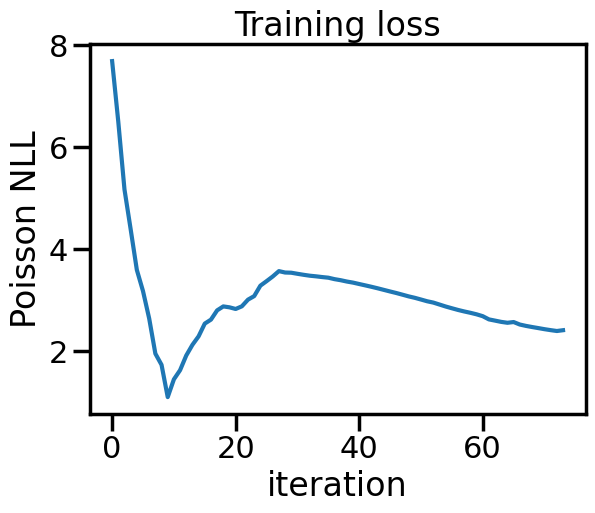

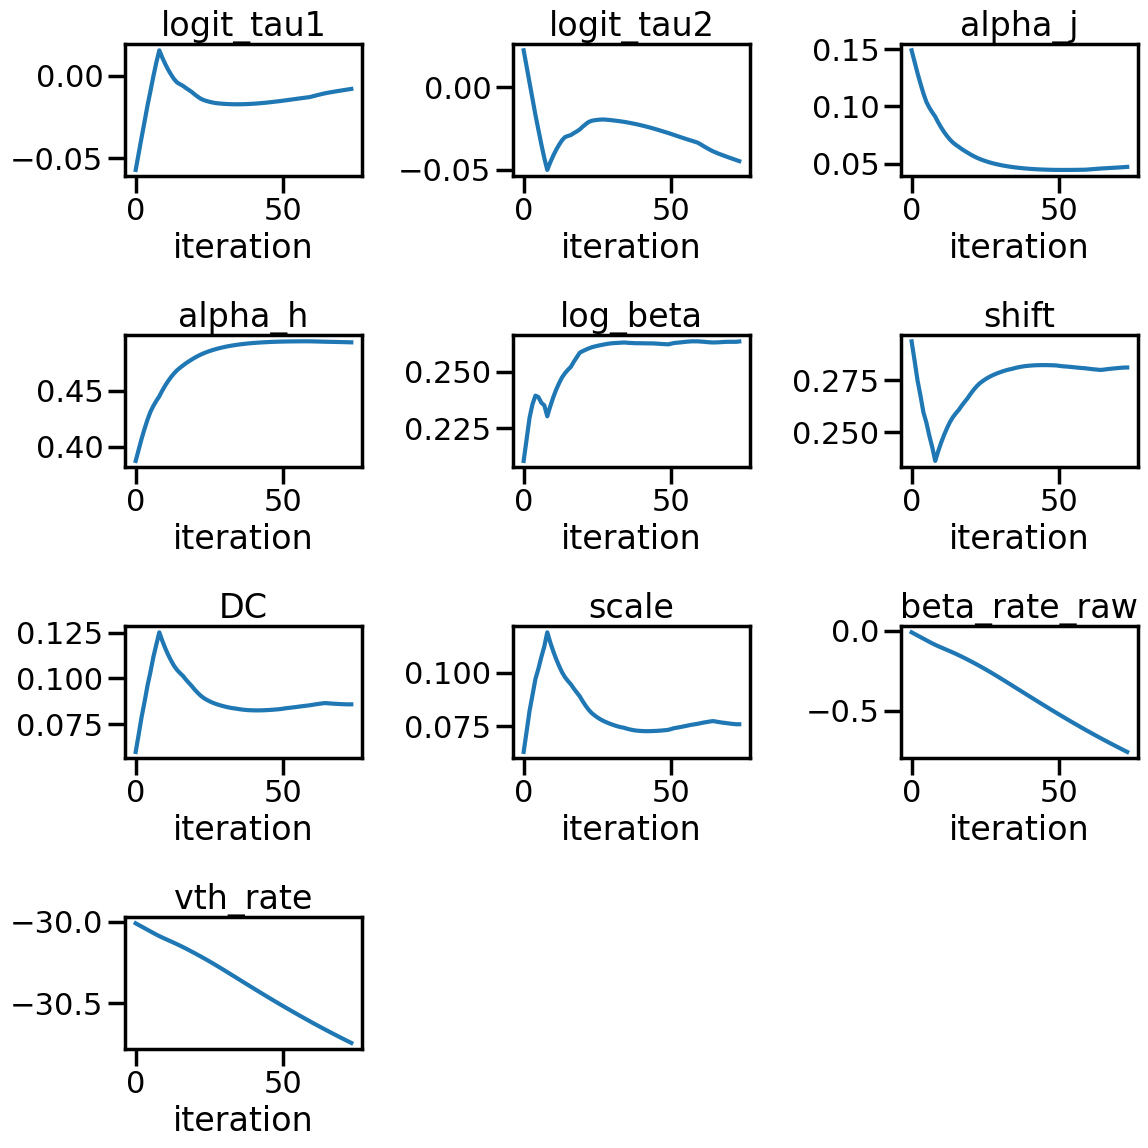

In [29]:
# ---- loss ----
plt.figure()
plt.plot(loss_hist)
plt.xlabel("iteration")
plt.ylabel("Poisson NLL")
plt.title("Training loss")
plt.show()

# ---- params (small multiples) ----
keys_to_plot = ["logit_tau1","logit_tau2","alpha_j","alpha_h","log_beta","shift","DC","scale","beta_rate_raw","vth_rate"]

n = len(keys_to_plot)
ncols = 3
nrows = int(np.ceil(n / ncols))

plt.figure(figsize=(12, 3*nrows))
for i, k in enumerate(keys_to_plot, 1):
    plt.subplot(nrows, ncols, i)
    plt.plot(hist[k])
    plt.title(k)
    plt.xlabel("iteration")
plt.tight_layout()
plt.show()


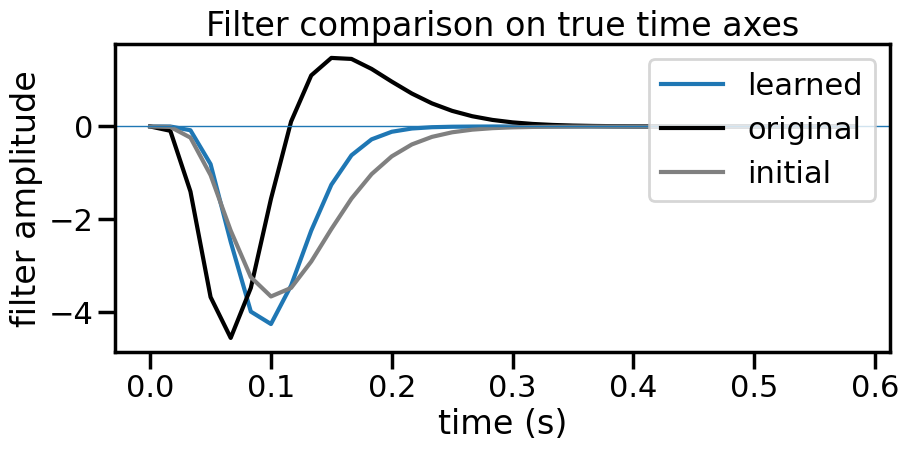

In [32]:
k, L, drive, beta, shift, tau_j, tau_h = get_ln_objects(
        params, stim, K_T=K_T, dt_stim=dt_stim, n=n, max_tau=max_tau
    )

k_np = np.array(jax.device_get(k))
Kground_np = np.array(jax.device_get(K_ground)) if hasattr(K_ground, "shape") else np.array(K_ground)

t_k = np.arange(len(k_np)) * float(dt_stim)     # seconds, since k uses dt_stim

# You must define dt_K for the original K. Common cases:
# - if K is per-frame too, dt_K = dt_stim
# - if K is at dt_cell_s or some other dt, set it accordingly
dt_K = dt_stim   # <-- CHANGE THIS to the correct timestep for K
t_K = np.arange(len(Kground_np)) * float(dt_K)

plt.figure(figsize=(10,4))
plt.plot(t_k, k_np, label="learned")
plt.plot(t_K, Kground_np, color="k", label="original")
plt.plot(t_K, K0, color="gray", label="initial")
plt.axhline(0, linewidth=1)
plt.xlabel("time (s)")
plt.ylabel("filter amplitude")
plt.legend(loc='upper right')
plt.title("Filter comparison on true time axes")
plt.show()


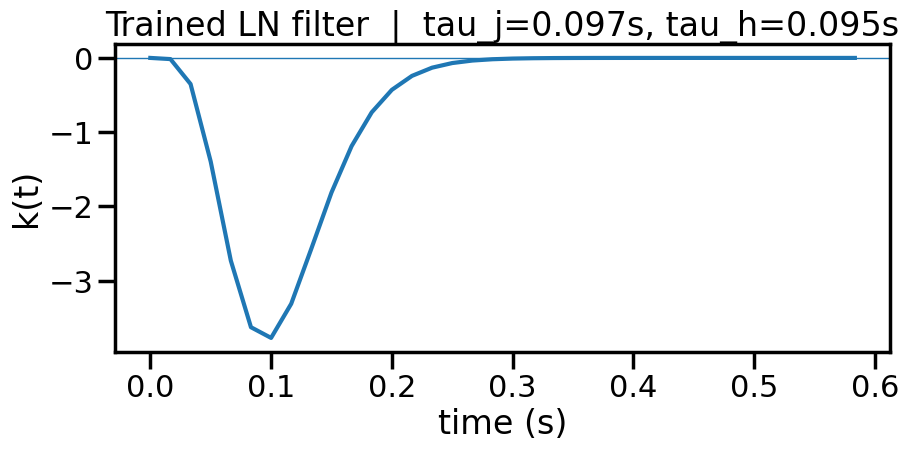

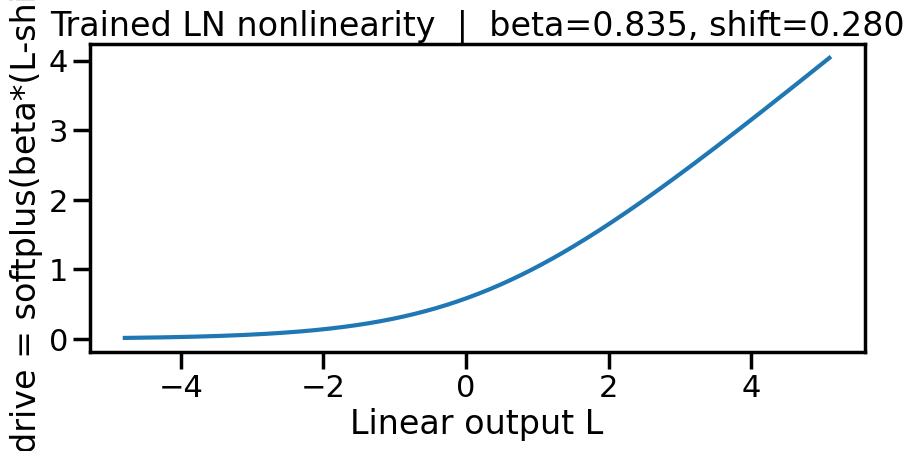

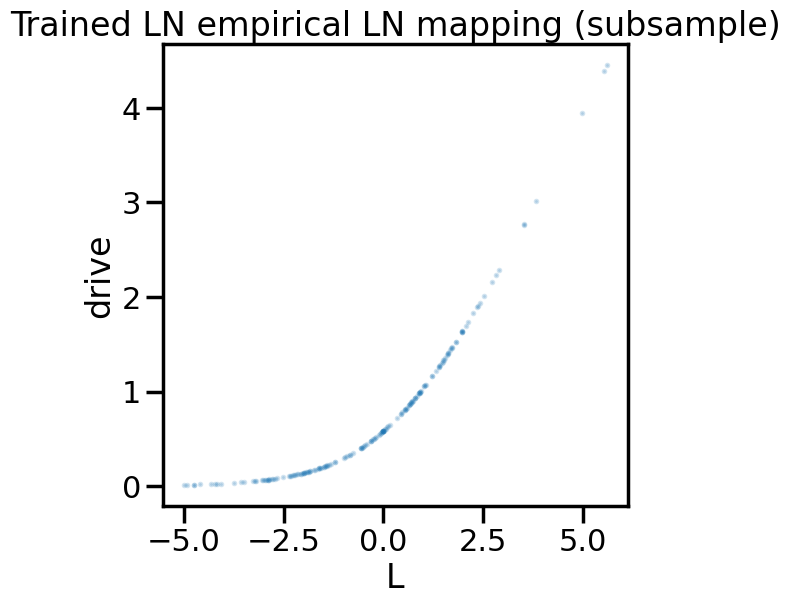

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax.nn import sigmoid, softplus

def get_ln_objects(params, stim, *, K_T, dt_stim, n, max_tau):
    # tau in seconds (since dt_stim is seconds)
    tau_j = sigmoid(params["logit_tau1"]) * max_tau
    tau_h = sigmoid(params["logit_tau2"]) * max_tau

    k = K_func(tau_j, tau_h, n, params["alpha_j"], params["alpha_h"], K_T, dt_stim)

    # L2 normalization (same as your ln_forward)
    eps = 1e-12
    k = k / (jnp.sqrt(jnp.sum(k**2) * dt_stim) + eps)

    # linear stage
    def conv1(tr):
        return jnp.convolve(tr, k, mode="full")[:tr.shape[0]]

    L = jax.vmap(conv1)(stim) if stim.ndim == 2 else conv1(stim)

    # nonlinearity params
    beta  = softplus(params["log_beta"]) + 1e-6
    shift = params["shift"]

    # drive
    drive = softplus(beta * (L - shift))
    return k, L, drive, beta, shift, tau_j, tau_h

def plot_filter_and_nl(params, stim, *, K_T, dt_stim, n, max_tau, title="LN"):
    k, L, drive, beta, shift, tau_j, tau_h = get_ln_objects(
        params, stim, K_T=K_T, dt_stim=dt_stim, n=n, max_tau=max_tau
    )

    # --- Filter plot ---
    t = np.arange(K_T) * float(dt_stim)  # seconds
    k_np = np.array(jax.device_get(k))

    plt.figure(figsize=(10,4))
    plt.plot(t, k_np)
    plt.xlabel("time (s)")
    plt.ylabel("k(t)")
    plt.title(f"{title} filter  |  tau_j={float(tau_j):.3f}s, tau_h={float(tau_h):.3f}s")
    plt.axhline(0, linewidth=1)
    plt.show()

    # --- NL curve plot ---
    # choose x-range from L distribution
    L_np = np.array(jax.device_get(L)).ravel()
    lo, hi = np.percentile(L_np, [1, 99])
    x = np.linspace(lo, hi, 400).astype(np.float32)

    beta_f  = float(jax.device_get(beta))
    shift_f = float(jax.device_get(shift))

    y = np.array(jax.device_get(softplus(beta * (jnp.array(x) - shift))))

    plt.figure(figsize=(10,4))
    plt.plot(x, y)
    plt.xlabel("Linear output L")
    plt.ylabel("drive = softplus(beta*(L-shift))")
    plt.title(f"{title} nonlinearity  |  beta={beta_f:.3f}, shift={shift_f:.3f}")
    plt.show()

    # --- Empirical LN scatter (optional but useful) ---
    drive_np = np.array(jax.device_get(drive)).ravel()

    plt.figure(figsize=(6,6))
    # subsample to keep it light
    idx = np.random.RandomState(0).choice(L_np.size, size=min(5000, L_np.size), replace=False)
    plt.scatter(L_np[idx], drive_np[idx], s=4, alpha=0.2)
    plt.xlabel("L")
    plt.ylabel("drive")
    plt.title(f"{title} empirical LN mapping (subsample)")
    plt.show()

plot_filter_and_nl(params, stim, K_T=K_T, dt_stim=dt_stim, n=6, max_tau=max_tau, title="Trained LN")
